
Projeto: Detecção de Spam WhatsApp

Integrantes:
- Danilo Tomas Tanganelli
- Igor Bragança
- Lucas Lucinio Cristovam





# IMPORTS


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# DATASET

In [16]:
df = pd.read_csv(
    "mensagens_spam.csv",
    encoding="utf-8",
    on_bad_lines="skip"
)

print(df.head())

                                    mensagem label
0  Parabéns! Você ganhou R$5000 clique agora  spam
1                Promoção imperdível só hoje  spam
2         Ganhe dinheiro trabalhando em casa  spam
3     URGENTE clique no link e receba prêmio  spam
4    Você foi selecionado para ganhar um PIX  spam


# ANÁLISE EXPLORATÓRIA


Distribuição das classes:
label
ham     6
spam    5
Name: count, dtype: int64


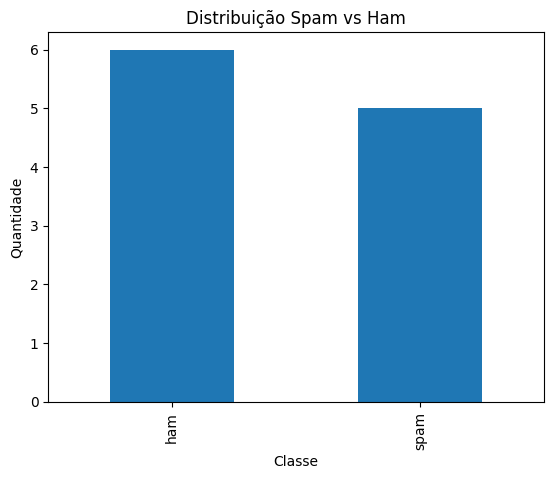

In [17]:
print("\nDistribuição das classes:")
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")

plt.title("Distribuição Spam vs Ham")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

# PRÉ-PROCESSAMENTO

In [18]:
def limpar_texto(texto):

    texto = texto.lower()

    texto = re.sub(r"http\S+", "", texto)

    texto = texto.translate(
        str.maketrans("", "", string.punctuation)
    )

    return texto

df["mensagem_limpa"] = df["mensagem"].apply(limpar_texto)

# TF-IDF

In [19]:

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["mensagem_limpa"])

y = df["label"]

# TRAIN TEST SPLIT

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MODELOS

In [21]:
modelos = {

    "Naive Bayes": MultinomialNB(),

    "Regressao Logistica": LogisticRegression(),

    "Random Forest": RandomForestClassifier()
}

# TREINAMENTO

In [22]:
for nome, modelo in modelos.items():

    print("\n")
    print("=" * 50)

    print(nome)

    print("=" * 50)

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)

    print("\nAccuracy:")
    print(accuracy_score(y_test, pred))

    print("\nClassification Report:")
    print(classification_report(y_test, pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, pred))



Naive Bayes

Accuracy:
0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

         ham       0.67      1.00      0.80         2
        spam       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3


Confusion Matrix:
[[2 0]
 [1 0]]


Regressao Logistica

Accuracy:
0.3333333333333333

Classification Report:
              precision    recall  f1-score   support

         ham       0.50      0.50      0.50         2
        spam       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3


Confusion Matrix:
[[1 1]
 [1 0]]


Random Forest

Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

         ham       1.00 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# TESTE INTERATIVO

In [23]:

modelo_final = LogisticRegression()

modelo_final.fit(X, y)

mensagem = ["Parabéns você ganhou um PIX clique aqui"]

mensagem_vetorizada = vectorizer.transform(mensagem)

resultado = modelo_final.predict(mensagem_vetorizada)

print("\nMensagem:")
print(mensagem[0])

print("\nResultado:")
print(resultado[0])


Mensagem:
Parabéns você ganhou um PIX clique aqui

Resultado:
spam
